# <font color=#2e86c1> Extracting decay rates for quantifying relaxation </font> 
SLEEPY provides some functionality for extracting decay rate constants directly from propagators, especially useful for the $R_{1\rho}$ experiment. We applied this function in the tutorial, but did not investigate it any deeper. Here, we investigate a little further.

### Imports

In [1]:
import sys
sys.path.append('/Users/albertsmith/Documents/GitHub/')

In [2]:
import SLEEPY as sl
import matplotlib.pyplot as plt
import numpy as np

Loading Defaults from file


## Define the experimental conditions
The initial setup follows the same procedure as the tutorial

In [52]:
# Calculate size of the one-bond dipole coupling for H–N
delta=sl.Tools.dipole_coupling(.102,'15N','1H')  #Distance, nuc1, nuc2

# Define field, nuclei, spinning speed, powder average
ex0=sl.ExpSys(v0H=500,Nucs=['15N','1H'],vr=60000,pwdavg=2)
# This powder average is too big, and we'll change it later
# We want it here for displaying the couplings

# Define interactions (dipole, CSA, chemical shift)
ex0.set_inter('dipole',i0=0,i1=1,delta=delta)
ex0.set_inter('CSA',i=0,delta=113,euler_d=[0,23,0])
ex0.set_inter('CS',i=0,ppm=-5)

# Copy system
ex1=ex0.copy()
# Redefine dipole, CSA, with same magnitude, but different orientation (20 degree hop)
ex1.set_inter('dipole',i0=0,i1=1,delta=delta,euler_d=[0,20,45])  
ex1.set_inter('CSA',i=0,delta=113,euler_d=[[0,23,0],[0,20,45]])
# Redefine chemical shift, with 10 ppm change
_=ex1.set_inter('CS',i=0,ppm=5)

## Add dynamics, create a sequence

In [53]:
L=sl.Liouvillian(ex0,ex1,kex=sl.Tools.twoSite_kex(tc=1e-4))
seq=L.Sequence()

## Create a density matrix, set detection operator

In [54]:
rho=sl.Rho('15Nx','15Nx')

**SLEEPY tip:** `rho.extract_decay_rates` examines the logarithm of the eigenvalues of a propagator and takes only the real values (the non-oscillatory terms), which give the rate of decay of those terms. Using the eigenvectors and the density and detection matrices, the amplitudes of these terms can be calculated. Then, this function returns the amplitude-weighted average rate. Note that when large oscillations are present, this sometimes includes negative amplitudes. It is then not so clear how to define the average, and the function can yield unreliable results. Changing the mode on `rho.extract_decay_rates` can also return the amplitudes and rates themselves, allowing one to construct an oscillation-free relaxation curve.

Below, we calculate the initial decay rate for a system near the rotational resonance recoupling (R$^3$) condition, where significant oscillations will be present.

In [55]:
seq.add_channel('15N',v1=55000)
U=seq.U()  #We need this more than once, so it's faster to calculate it.
rho.clear()
Ravg=rho.extract_decay_rates(U)
print(f'Initial decay rate: {Ravg:.1f} s^-1')

State-space reduction: 32->16
Initial decay rate: 301.7 s^-1


Construct an oscillation-free curve.

Every orientation will produce different relaxation rates, and in fact each single orientation produces two rates that make significant contributions to the relaxation curve. These correspond to the dipole and CSA relaxation being additive and subtractive.

(A closer look will reveal additional, usually very fast rates, but with very low amplitude contributions)

In [56]:
rho.clear()
R,A=rho.extract_decay_rates(U,mode='wt_rates')
_=rho.DetProp(U,n=6000)

I=np.sum([A0*np.exp(-R0*rho.t_axis) for R0,A0 in zip(R,A)],axis=0)

State-space reduction: 32->16
State-space reduction: 32->16


## Compare relaxation curves
* Full simulation
* Calculated decay with oscillation removed
* Monoexponential decay
  Same average relaxation/same initial decay rate

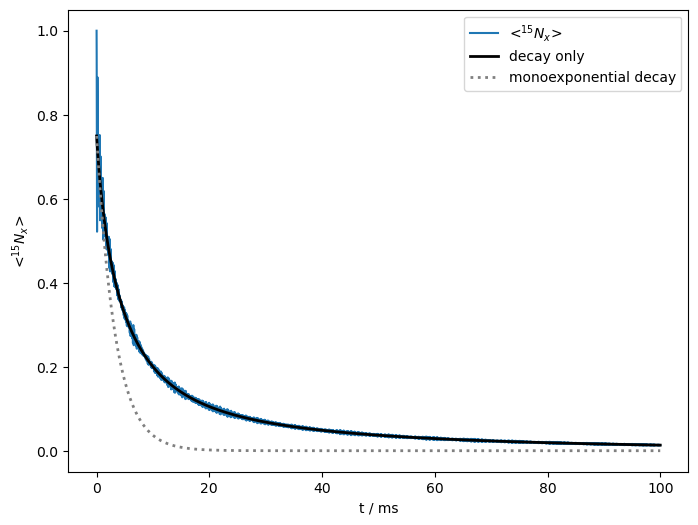

In [58]:
ax=rho.plot()
ax.figure.set_size_inches([8,6])
ax.plot(rho.t_axis*1e3,I,color='black',linewidth=2,label='decay only')
ax.plot(rho.t_axis*1e3,I[0]*np.exp(-Ravg*rho.t_axis),
        color='grey',linestyle=':',linewidth=2,label='monoexponential decay')
_=ax.legend()

Above, we have plotted the simulated relaxation data, including oscillations, a back-calculation of the relaxation curve where oscillations have been eliminated. The initial decay rate of this curve is also the average relaxation rate constant. Finally, we calculate a mono-exponentially decaying curve with the same rate constant as the average for the black curve. 

What we notice is that while the initial decay rate matches, the two curves deviate quickly due to the multi-exponentiality of the real decay. This arises both because of different orientations in the powder average and additive/substractive contributions from the CSA and dipole relaxation.